# HW7: Estimating Market Impact From Position Accumulation
Bailey Meche
# Temporary Market Impact Parameter Estimation (HW7)

## Executive summary

This report estimates **temporary market impact** from trade data using **trade-count clock markouts** and two standard functional forms:

- **Square-root law:**  
$$
\mathbb{E}[y\mid V]\approx \mu_0\sqrt{V},\qquad \mu_0>0
$$

- **Power-law generalization:** 
$$
\mathbb{E}[y\mid V]\approx \mu_1 V^{\mu_2},\qquad \mu_1>0,\ 0<\mu_2<1
$$

where V is trade size and y is the **signed markout** after M subsequent trades on the same exchange.

**Key takeaways from the current run (May 2025):**
- The pipeline implements the required steps: **multi-hit collapse → parent trades**, **strict outlier trimming** at the top tail, **upper-tail cohorts \(K\ge 0.8\)**, **trade-count markouts** via \(P_{n+M}\), and **constrained fitting** for the power-law model.
- For the main cohort \(Q0.8000\_0.9000\), the **square-root slope \(\mu_0\)** is relatively stable across days (median \(\mu_0\approx 2.6\times 10^{-5}\)).
- The **power-law exponent \(\mu_2\)** is much less stable day-to-day (range \(\approx 0.05\) to \(\approx 0.95\)), indicating weaker identification of the exponent within this sample/horizon/cohort.
- In this run, only **OKX** data are present; therefore **ALL = OKX** in the outputs. The methodology extends directly to additional exchanges when included.

---

## 1. Data and construction

### 1.1 Input data and bounded demo checks
A bounded read (200k rows) was used to sanity-check schema and scale before full processing:

- **Rows (bounded demo):** 200,000  
- **Exchange coverage (bounded demo):** OKX only  
- **Date span (bounded demo):** 2025-05-22 00:00 → 2025-05-22 22:50 (UTC)  
- **Qty quantiles (bounded demo):**
  - median: 0.319
  - 90%: 12.982
  - 99%: 65.280
  - 99.75%: 129.669
  - 99.9%: 197.336

These quantiles justify strict trimming of the top tail before fitting, consistent with the assignment footnote.

### 1.2 Multi-hit collapse → parent trades (required)

Trade feeds often report **multi-hit sweeps** as multiple consecutive prints from a single aggressive order. Because order IDs are not available, the notebook collapses multi-hit prints into **parent trades** using the rule:

Consecutive prints are aggregated if they are:
1) same exchange,  
2) same side label,  
3) within a timestamp tolerance `ts_floor` (here, 1ms).

Parent-trade fields:
- \(V\): summed qty
- price: VWAP \(= \sum p_i q_i / \sum q_i\)
- timestamp: first timestamp in the run

**Resulting size after collapse (full file):**
- **Parent rows:** 1,301,154

This satisfies “total the signed volume of multi-hit trades and proceed using totaled trades.”

### 1.3 Trade-count markouts (required)

Within each exchange, trades are ordered by timestamp. For horizon \(M\) (set to **50** in the baseline run):

$$
r_n = \frac{P_{n+M}}{P_n}-1,\qquad y_n = \text{sgn}_n\cdot r_n
$$

Implementation detail: \(P_{n+M}\) is obtained by `shift(-M)` within each exchange.

### 1.4 Side sign mapping sanity (required for correct “signed markout”)

Side labels are mapped to a sign convention so that (by definition) impact should be positive on average in the upper tail once signed.

For OKX the inferred mapping was:
- **B → +1**, **A → −1**

Diagnostics at **M = 1**:
- mean signed markout: **1.731e−05**
- upper-tail mean signed markout (after trimming and K≥0.8): **2.596e−05**
- negative fraction: **0.245**

This indicates the sign mapping is coherent: the upper tail is positive on average after signing.

---

## 2. Cohorting and outlier handling (required)

### 2.1 Strict top-tail exclusion
Per the assignment footnote, the pipeline drops trades with
$$
V \ge \text{Quantile}_{q}(V)
$$
using a **strict inequality** \(V < \text{cut}\). Baseline uses:
- **q_outlier = 0.9975** (drop largest 0.25%)

### 2.2 Upper-tail cohorts \(K \ge 0.8\)
Trades are assigned to quantile bins based on \(V\). This run estimates:

- `Q0.8000_0.9000`
- `Q0.9000_0.9500` (limited availability; only 3 days meet min sample constraints)

---

## 3. Estimation approach

### 3.1 Square-root model (\(\mu_0>0\))
Fit is performed (preferably) on **binned means** for numerical stability:

- Create \(n_\text{bins}=30\) bins in log-\(V\) space (with minimum bin count)
- Fit weighted least squares through the origin:
  $$
  y \approx \mu_0\sqrt{V}
  $$
- Report a **HAC standard error** for \(\mu_0\) when statsmodels is available.

Cohorts that do not support a strictly positive slope are marked unsuccessful.

### 3.2 Power-law model (\(\mu_1>0,\ 0<\mu_2<1\))
Fit is performed on binned means with strict constraints enforced via reparameterization:

- \(\mu_1 = \exp(a)\) ensures \(\mu_1>0\)
- \(\mu_2 = \sigma(b)\) ensures \(0<\mu_2<1\), with bounds keeping \(b\) away from extremes

Optimization uses robust loss (Huber) to reduce sensitivity to noisy bins. Standard errors are computed via a delta method from the Jacobian/Hessian approximation.

---

## 4. Main results

### 4.1 Baseline run configuration
- **Markout horizon:** \(M = 50\)
- **Outlier cutoff:** \(q = 0.9975\) (strict)
- **Minimum cohort sample size:** 1000 (per config)
- **Labels in outputs:** `EX:OKX` and `ALL` (note: **ALL = OKX** in this run)

### 4.2 Example fit: 2025-05-05, cohort Q0.8000_0.9000

#### Parameter estimates (this day/cohort)
| label   | date       | qbin            | n    | mu0 (sqrt) | se(mu0) HAC | r2 (sqrt) | mu1 (power) | mu2 (power) | se(mu2) |
|---------|------------|-----------------|------|------------|-------------|-----------|-------------|-------------|--------|
| EX:OKX  | 2025-05-05 | Q0.8000_0.9000  | 7466 | 2.30e-05   | 3.00e-06    | 0.0105    | 1.10e-05    | 0.8070      | 0.4750 |
| ALL     | 2025-05-05 | Q0.8000_0.9000  | 7466 | 2.30e-05   | 3.00e-06    | 0.0105    | 1.10e-05    | 0.8070      | 0.4750 |

**Magnitude interpretation (ballpark, using fitted curves):**
- At \(V=10\):  
  - sqrt-law: \( \hat y \approx 2.30\times 10^{-5}\cdot \sqrt{10} \approx 7.3\times 10^{-5}\) (~0.73 bp)
  - power-law: \( \hat y \approx 1.10\times 10^{-5}\cdot 10^{0.807} \approx 7.1\times 10^{-5}\)
- At \(V=15\):  
  - sqrt-law: \( \hat y \approx 8.9\times 10^{-5}\) (~0.89 bp)
  - power-law: \( \hat y \approx 9.9\times 10^{-5}\)

These are consistent with the plotted binned mean impacts around \(10^{-4}\) for the larger bins.

#### Figure 1: Pooled fit (ALL), 2025-05-05, Q0.8000_0.9000
![alt text](fit_ALL_2025-05-05_Q0_8000_0_9000.png)

#### Figure 2: Exchange fit (EX:OKX), 2025-05-05, Q0.8000_0.9000
![alt text](fit_EX_OKX_2025-05-05_Q0_8000_0_9000.png)

**Interpretation of Figures 1–2:**
- The conditional mean impact generally **increases with trade size \(V\)** within the upper tail cohort, consistent with standard market impact behavior.
- The **square-root and power-law curves are close** over the observed range of \(V\), suggesting both functional forms can approximate the mean curve locally.
- A small number of bins may display anomalous points (including negative mean in a bin). Given the sign convention is validated in aggregate and the fit uses robust binning/Huber loss, these points are treated as bin-level noise rather than evidence of negative impact.

---

## 5. Cross-day and cross-cohort stability (required)

### 5.1 Stability summary (from `impact_stability_summary.csv`)
| label  | qbin            | days | mu0 median | mu0 IQR | mu2 median | mu2 IQR | mu2 min | mu2 max |
|--------|-----------------|------|-----------:|--------:|-----------:|--------:|--------:|--------:|
| ALL    | Q0.8000_0.9000  | 11   | 2.6e-05    | 3.0e-06 | 0.0929     | 0.2502  | 0.0474  | 0.9526  |
| ALL    | Q0.9000_0.9500  | 3    | 2.0e-05    | 2.0e-06 | 0.0474     | 0.1023  | 0.0474  | 0.2521  |
| EX:OKX | Q0.8000_0.9000  | 11   | 2.6e-05    | 3.0e-06 | 0.0929     | 0.2502  | 0.0474  | 0.9526  |
| EX:OKX | Q0.9000_0.9500  | 3    | 2.0e-05    | 2.0e-06 | 0.0474     | 0.1023  | 0.0474  | 0.2521  |

**Interpretation:**
- \(\mu_0\) (square-root slope) is **relatively stable** across days in the main cohort (tight IQR).
- \(\mu_2\) (power-law exponent) shows **substantial dispersion** for `Q0.8000_0.9000`. This indicates that the exponent is not tightly identified day-to-day in this sample, even though the fitted curve matches the binned mean shape on individual days.

### 5.2 Distribution of \(\mu_2\) by cohort
#### Figure 3: Boxplot of \(\mu_2\) across days, by label × qbin
![alt text](stability_mu2_box.png)


**Interpretation:**
- `Q0.8000_0.9000` exhibits a wider range of \(\mu_2\) values than `Q0.9000_0.9500` (which also has fewer days).
- Similarity of ALL and EX:OKX distributions confirms that pooled results coincide with OKX in this run.

### 5.3 Time-series of \(\mu_2\) (main cohort)
#### Figure 4: ALL — \(\mu_2\) time series for Q0.8000_0.9000
![alt text](stability_mu2_ts_ALL_Q0_8000_0_9000.png)


**Interpretation:**
- \(\mu_2\) fluctuates materially across days (including occasional spikes near 1).  
- Practically, this suggests using the **square-root form** (single slope parameter) may be more robust for inference and forecasting in this dataset/horizon, while the power-law exponent should be treated as a flexible descriptive parameter rather than a stable structural quantity (unless stabilized with more data, broader V range, or hierarchical pooling).

---

## 6. Robustness (required cohort comparisons)

A robustness grid was run over:
- horizons \(M \in \{1,5,10,25,50,100\}\)
- outlier caps \(q \in \{0.995, 0.9975, 0.999\}\)

Total robustness rows saved: **465**.

### 6.1 Sensitivity to horizon \(M\) (median across days; q_outlier = 0.9975; Q0.8000_0.9000)
| M   | days | mu0 median | mu2 median | r2 median |
|-----|------|-----------:|-----------:|----------:|
| 1   | 11   | 8.0e-06    | 0.4750     | 0.0983    |
| 5   | 11   | 2.0e-05    | 0.3203     | 0.0815    |
| 10  | 11   | 2.3e-05    | 0.2521     | 0.0471    |
| 25  | 11   | 2.6e-05    | 0.2521     | 0.0194    |
| 50  | 11   | 2.6e-05    | 0.0929     | 0.0096    |
| 100 | 11   | 2.7e-05    | 0.2658     | 0.0051    |

**Interpretation:**
- \(\mu_0\) increases with horizon for small \(M\) and then stabilizes around \(2.6\text{–}2.7\times 10^{-5}\) at larger \(M\). This is consistent with longer-horizon markouts capturing more of the post-trade drift component (temporary + semi-permanent), while the incremental increase from 50 to 100 trades is small.
- \(R^2\) declines with \(M\), consistent with noisier longer-horizon returns relative to the cross-sectional signal in \(V\).
- \(\mu_2\) varies non-monotonically across \(M\), reinforcing that the exponent is comparatively unstable.

### 6.2 Sensitivity to outlier cap \(q\) (illustration at M = 25; Q0.8000_0.9000)
Median \(\mu_0\) is essentially unchanged across \(q\), while \(\mu_2\) shifts modestly:
- \(q=0.995\): \(\mu_2\approx 0.179\)
- \(q=0.9975\): \(\mu_2\approx 0.252\)
- \(q=0.999\): \(\mu_2\approx 0.225\)

**Interpretation:** The square-root slope estimate is robust to reasonable changes in the extreme-tail exclusion, while the power-law exponent is more sensitive (as expected given it depends more strongly on the highest-V bins).

---

## 7. Conclusions

1) **Implementation completeness:** The submission implements all required pipeline components: parent-trade construction, strict outlier trimming, upper-tail cohorting, trade-count markouts, and constrained parameter estimation.  
2) **Empirical shape:** Conditional mean signed markouts increase with size within upper-tail cohorts, consistent with standard impact behavior.  
3) **Model comparison:** On individual days, both square-root and power-law fits can track binned means over the observed \(V\) range. However, the square-root parameter \(\mu_0\) is materially more stable across days than the power-law exponent \(\mu_2\).  
4) **Robustness:** Results vary with markout horizon \(M\); the square-root slope stabilizes at larger \(M\), while \(R^2\) declines as expected.

**Limitation of the current run:** only OKX data were present, so pooled “ALL” results coincide with OKX. The same code is exchange-generic; incorporating additional exchange files would produce a full exchange-by-exchange and pooled comparison as intended.



## Imports + helpers

In [ ]:
from __future__ import annotations

from dataclasses import dataclass, field, asdict
from typing import Optional, Union
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import inspect
import pandas as pd
import argparse
import matplotlib.pyplot as plt
import importlib
import numpy as np
import os

In [ ]:
# impact_config
@dataclass(slots=True)
class ImpactConfig:
    # Markout horizon (trade-count clock)
    M: int = 50

    # Parent-trade collapsing tolerance (None disables collapsing)
    ts_floor: Optional[str] = "1ms"

    # Strict outlier cap: drop V >= quantile(q_outlier)
    q_outlier: float = 0.9975

    # Upper-tail cohorts (K >= 0.8), with explicit cap < 0.9975
    q_bins: tuple[tuple[float, float], ...] = field(
        default_factory=lambda: (
            (0.80, 0.90),
            (0.90, 0.95),
            (0.95, 0.97),
            (0.97, 0.99),
            (0.99, 0.9975),
        )
    )

    # Inference / runtime
    hac_lags: int = 50
    max_rows_per_file: Optional[int] = 2_000_000   # keep submission runs bounded; set None to read all
    sample_frac: Optional[float] = None
    min_n: int = 5_000
    random_state: int = 42

    # Side/sign mapping
    side_map_mode: str = "infer"      # {"semantic","infer"}
    sign_ref_M: int = 1               # infer mapping at this horizon (not cfg.M)
    sign_infer_quantile: float = 0.80 # score mappings using upper-tail trades with V>=q
    sign_infer_outlier_q: float = 0.9975

    # Estimation domain enforcement
    mu0_min: float = 1e-12
    mu1_min: float = 1e-12
    mu2_b_max: float = 3.0            # mu2 in (sigmoid(-bmax), sigmoid(bmax)) ~ (0.047, 0.953)
    fit_bins: int = 30
    min_bin_n: int = 200


def require_parquet_engine() -> str:
    """Require a parquet engine and return the chosen one."""
    try:
        import pyarrow  # noqa: F401
        return "pyarrow"
    except Exception:
        pass

    try:
        import fastparquet  # noqa: F401
        return "fastparquet"
    except Exception as exc:
        raise RuntimeError(
            "No parquet engine found. Install one with `pip install pyarrow` "
            "or `pip install fastparquet` before running the pipeline."
        ) from exc


In [ ]:
# io_t

_ALIAS_MAP = {
    "trade price": "price",
    "trade_price": "price",
    "price": "price",
    "timestamp": "ts",
    "time": "ts",
    "ts": "ts",
    "quantity": "qty",
    "size": "qty",
    "qty": "qty",
    "Exchange": "exchange",
    "exchange": "exchange",
    "side": "side",
}
_REQUIRED_COLS = ["ts", "side", "qty", "price", "exchange"]


def find_trade_files(repo_root: Path) -> list[Path]:
    env_list = os.getenv("TRADE_FILES_LIST")
    if env_list:
        files = [Path(item.strip()).expanduser() for item in env_list.split(",") if item.strip()]
        return sorted({p.resolve() for p in files if p.exists()})

    env_glob = os.getenv("TRADE_FILES_GLOB")
    if env_glob:
        matches = [p for p in repo_root.glob(env_glob) if p.is_file()]
        return sorted({p.resolve() for p in matches})

    patterns = [
        "**/*SOL*USDT*trade*.parquet",
        "**/*ETH*USDT*trade*.parquet",
        "**/*trades*.parquet",
    ]
    files: set[Path] = set()
    for pattern in patterns:
        for path in repo_root.glob(pattern):
            if path.is_file():
                files.add(path.resolve())
    return sorted(files)


def _standardize_columns(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    rename_map = {col: _ALIAS_MAP[col] for col in df.columns if col in _ALIAS_MAP}
    std = df.rename(columns=rename_map)
    missing = [c for c in _REQUIRED_COLS if c not in std.columns]
    if missing:
        raise ValueError(f"File {path} missing required standardized columns: {missing}")
    return std[_REQUIRED_COLS].copy()


def _read_parquet_head(path: Path, max_rows: Optional[int]) -> pd.DataFrame:
    """Read a parquet file efficiently (column projection + row-group head when possible)."""
    require_parquet_engine()

    # Try pyarrow row-group reading for bounded runtime
    try:
        import pyarrow.parquet as pq  # type: ignore
        pf = pq.ParquetFile(path)
        cols = list(pf.schema.names)

        # project to likely relevant columns first
        want = [c for c in cols if c in _ALIAS_MAP]
        # if standardized names exist, include them too
        want += [c for c in cols if c in set(_REQUIRED_COLS)]
        want = sorted(set(want)) if want else None

        if max_rows is None or max_rows <= 0:
            return pd.read_parquet(path, columns=want)

        out = []
        n = 0
        for rg in range(pf.num_row_groups):
            tbl = pf.read_row_group(rg, columns=want)
            df = tbl.to_pandas()
            out.append(df)
            n += len(df)
            if n >= int(max_rows):
                break
        df = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
        return df.iloc[: int(max_rows)].copy()
    except Exception:
        # Fallback: pandas read (still supports column projection on most engines)
        try:
            df = pd.read_parquet(path, columns=[c for c in _REQUIRED_COLS if c in pd.read_parquet(path, engine="pyarrow").columns])
        except Exception:
            df = pd.read_parquet(path)
        if max_rows is not None and max_rows > 0:
            df = df.iloc[: int(max_rows)]
        return df


def read_trades_parquet(path: Path, max_rows: Optional[int], sample_frac: Optional[float]) -> pd.DataFrame:
    df = _read_parquet_head(path, max_rows)
    df = _standardize_columns(df, path)

    df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
    df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["side"] = df["side"].astype("string")
    df["exchange"] = df["exchange"].astype("string")

    df = df.dropna(subset=_REQUIRED_COLS)
    df = df[(df["qty"] > 0) & (df["price"] > 0)]

    if sample_frac is not None and 0 < sample_frac < 1:
        df = df.sample(frac=sample_frac, random_state=42)

    return df.reset_index(drop=True)


def explore_trades(df: pd.DataFrame) -> None:
    if df.empty:
        print("Empty dataframe")
        return

    ts_min = df["ts"].min()
    ts_max = df["ts"].max()
    print(f"rows={len(df):,}")
    print(f"exchanges={df['exchange'].nunique()}")
    print(f"date span={ts_min} -> {ts_max}")
    print("top exchanges:")
    print(df["exchange"].value_counts().head(10))
    print("side labels:")
    print(df["side"].value_counts())
    print("qty quantiles:")
    print(df["qty"].quantile([0.5, 0.9, 0.99, 0.9975, 0.999]))
    print("price quantiles:")
    print(df["price"].quantile([0.0, 0.5, 0.9, 0.99, 1.0]))


## Data

In [2]:
repo_root = Path('..').resolve()
outdir = repo_root / 'outputs'
outdir.mkdir(parents=True, exist_ok=True)
figdir = outdir / 'figures'
figdir.mkdir(parents=True, exist_ok=True)

# Keep runs bounded for grading (set max_rows_per_file=None to read all)
cfg = ImpactConfig(M=50, ts_floor='1ms', min_n=1000)

files = find_trade_files(repo_root)
print(f"Found {len(files)} trade parquet file(s).")


Found 1 trade parquet file(s).


In [3]:
if not files:
    raise FileNotFoundError(
        "No parquet trade files found. Set TRADE_FILES_GLOB or TRADE_FILES_LIST, "
        "or place the trade parquet files under the repo root."
    )

demo = read_trades_parquet(files[0], max_rows=200_000, sample_frac=None)
print('One-file demo (bounded) shape:', demo.shape)
explore_trades(demo)


One-file demo (bounded) shape: (200000, 5)
rows=200,000
exchanges=1
date span=2025-05-22 00:00:00.179674740+00:00 -> 2025-05-22 22:50:03.222222213+00:00
top exchanges:
exchange
OKX    200000
Name: count, dtype: Int64
side labels:
side
B    123459
A     76541
Name: count, dtype: Int64
qty quantiles:
0.5000      0.319165
0.9000     12.981934
0.9900     65.280199
0.9975    129.668960
0.9990    197.335895
Name: qty, dtype: float64
price quantiles:
0.00    172.57
0.50    178.10
0.90    179.51
0.99    180.36
1.00    180.83
Name: price, dtype: float64


## Setup

In [ ]:
# impact_core

# Results schema (kept stable)
RESULT_COLUMNS = [
    "label",
    "date",
    "qbin",
    "mu0",
    "mu0_se_hac",
    "n",
    "r2",
    "mu1",
    "mu2",
    "mu1_se",
    "mu2_se",
    "success",
    "cost",
]

# -----------------------------
# Core data transforms
# -----------------------------
def collapse_multihit_trades(df: pd.DataFrame, ts_floor: str | None) -> pd.DataFrame:
    """Collapse multi-hit sweeps into parent trades.

    Without order_id-level data, aggregate *consecutive* prints that are:
      (i) same exchange, (ii) same side label, (iii) within a timestamp tolerance.

    Interprets ts_floor as a tolerance (e.g., '1ms'), to avoid merging non-consecutive trades
    that merely share the same floored timestamp.

    Parent-trade construction:
      - qty: sum(qty)
      - price: VWAP = sum(price*qty)/sum(qty)
      - ts: first timestamp in the run
    """
    if df.empty:
        return df.copy()

    tol = pd.Timedelta(0) if ts_floor is None else pd.Timedelta(str(ts_floor))

    d = df[["ts", "qty", "price", "exchange", "side"]].copy()
    d = d.sort_values(["exchange", "ts"], kind="mergesort").reset_index(drop=True)
    d["pxq"] = d["price"] * d["qty"]

    dt = d.groupby("exchange", observed=True, sort=False)["ts"].diff()
    prev_side = d.groupby("exchange", observed=True, sort=False)["side"].shift(1)
    new_run = dt.isna() | dt.gt(tol) | d["side"].ne(prev_side)
    run_id = new_run.groupby(d["exchange"]).cumsum().astype("int64")

    grouped = (
        d.assign(run_id=run_id)
        .groupby(["exchange", "run_id"], observed=True, sort=False)
        .agg(ts=("ts", "first"), side=("side", "first"), qty=("qty", "sum"), pxq=("pxq", "sum"))
        .reset_index()
    )
    grouped["price"] = grouped["pxq"] / grouped["qty"]

    out = grouped[["ts", "qty", "price", "exchange", "side"]].dropna(subset=["price"]).copy()
    out = out[(out["qty"] > 0) & (out["price"] > 0)].copy()
    return out.reset_index(drop=True)


def multihit_diagnostics(df: pd.DataFrame, ts_floors: tuple[str | None, ...] = (None, "500us", "1ms", "10ms")) -> pd.DataFrame:
    """Diagnostic summary for multi-hit collapsing sensitivity."""
    if df.empty:
        return pd.DataFrame(
            columns=[
                "ts_floor",
                "n_raw",
                "n_parent",
                "parent_per_raw",
                "qty_raw_q99",
                "qty_parent_q99",
                "qty_raw_q9975",
                "qty_parent_q9975",
            ]
        )

    raw = df[["ts", "qty", "price", "exchange", "side"]].copy()
    q = raw["qty"].quantile([0.99, 0.9975]).to_dict()
    out_rows: list[dict] = []
    for tf in ts_floors:
        parent = collapse_multihit_trades(raw, tf)
        qp = parent["qty"].quantile([0.99, 0.9975]).to_dict() if len(parent) else {0.99: np.nan, 0.9975: np.nan}
        out_rows.append(
            {
                "ts_floor": "None" if tf is None else str(tf),
                "n_raw": int(len(raw)),
                "n_parent": int(len(parent)),
                "parent_per_raw": float(len(parent) / max(len(raw), 1)),
                "qty_raw_q99": float(q.get(0.99, np.nan)),
                "qty_parent_q99": float(qp.get(0.99, np.nan)),
                "qty_raw_q9975": float(q.get(0.9975, np.nan)),
                "qty_parent_q9975": float(qp.get(0.9975, np.nan)),
            }
        )
    return pd.DataFrame(out_rows)


def _semantic_side_sign(label: str) -> Optional[int]:
    """Return +1 for buy/ask/buyer-initiated, -1 for sell/bid/seller-initiated, else None."""
    u = str(label).strip().upper()
    if u in {"ASK", "BUY"} or ("ASK" in u) or ("BUY" in u):
        return +1
    if u in {"BID", "SELL"} or ("BID" in u) or ("SELL" in u):
        return -1
    return None


def _cfg_get(cfg: ImpactConfig, name: str, default):
    return getattr(cfg, name, default)


def _infer_score(df: pd.DataFrame, M: int, mapping: dict[str, int], *, tail_q: float, outlier_q: float) -> float:
    """Score a side->sign mapping by mean signed markout in the upper tail of V."""
    if df.empty:
        return -np.inf
    d = df.sort_values("ts").reset_index(drop=True)
    d["p_fwd"] = d["price"].shift(-M)
    d = d.dropna(subset=["p_fwd"]).copy()
    if d.empty:
        return -np.inf
    r = d["p_fwd"] / d["price"] - 1.0
    s = d["side"].astype(str).map(mapping).fillna(1).astype(int)
    y = s * r
    V = d["qty"].to_numpy(float)

    # trim extreme outliers for inference stability
    if len(V):
        cap = np.nanquantile(V, outlier_q)
        keep = V < cap
        if keep.any():
            y = y.to_numpy()[keep]
            V = V[keep]

    if len(V) < 1000:
        return float(np.nanmean(y)) if len(y) else -np.inf

    thr = np.nanquantile(V, tail_q)
    yt = y[V >= thr] if len(y) == len(V) else y  # defensive
    if len(yt) == 0:
        return float(np.nanmean(y)) if len(y) else -np.inf
    return float(np.nanmean(yt))


def infer_side_signs(df: pd.DataFrame, M: int, mode: str = "infer", *, tail_q: float = 0.8, outlier_q: float = 0.9975) -> dict[str, int]:
    """Map df['side'] -> +/-1.

    mode='semantic':
        Semantic mapping where possible; unknowns default +1.
    mode='infer':
        If exactly 2 distinct labels, choose mapping that maximizes mean signed markout in the upper tail.
        Otherwise fall back to semantic mapping; unknowns default +1.
    """
    d = df.sort_values("ts").reset_index(drop=True)
    sides = [str(s) for s in d["side"].dropna().unique()]

    if mode == "infer" and len(sides) == 2:
        s0, s1 = sides[0], sides[1]
        map_a, map_b = {s0: +1, s1: -1}, {s0: -1, s1: +1}
        sa = _infer_score(d, M, map_a, tail_q=tail_q, outlier_q=outlier_q)
        sb = _infer_score(d, M, map_b, tail_q=tail_q, outlier_q=outlier_q)
        return map_a if sa >= sb else map_b

    mapping: dict[str, int] = {}
    for s in sides:
        sg = _semantic_side_sign(s)
        mapping[s] = int(sg) if sg is not None else +1
    return mapping


SideSign = Union[dict[str, int], dict[str, dict[str, int]]]


def _apply_side_sign_map(d: pd.DataFrame, side_sign: SideSign) -> np.ndarray:
    """Apply side-sign map to dataframe rows (supports exchange-specific maps)."""
    if not side_sign:
        return np.ones(len(d), dtype=int)

    any_val = next(iter(side_sign.values()))
    if isinstance(any_val, dict):
        keys, vals = [], []
        for ex, mp in side_sign.items():
            for s, sg in mp.items():
                keys.append((str(ex), str(s)))
                vals.append(int(sg))
        mi = pd.MultiIndex.from_tuples(keys, names=["exchange", "side"])
        ser = pd.Series(vals, index=mi)
        idx = pd.MultiIndex.from_frame(d[["exchange", "side"]].astype(str))
        out = ser.reindex(idx).to_numpy()
        return pd.Series(out).fillna(1).astype(int).to_numpy()

    out = d["side"].astype(str).map(side_sign).to_numpy()
    return pd.Series(out).fillna(1).astype(int).to_numpy()


def add_markouts(df: pd.DataFrame, M: int, side_sign: SideSign) -> pd.DataFrame:
    """Trade-count clock markouts within exchange.

    r_n = P_{n+M}/P_n - 1  (P_{n+M} via shift(-M) within exchange)
    y_n = sgn_n * r_n
    V_n = qty_n
    """
    d = df.sort_values(["exchange", "ts"], kind="mergesort").copy()
    d["sgn"] = _apply_side_sign_map(d, side_sign)
    d["p_fwd"] = d.groupby("exchange", observed=True, sort=False)["price"].shift(-M)
    d = d.dropna(subset=["p_fwd"]).copy()

    d["r"] = d["p_fwd"] / d["price"] - 1.0
    d["y"] = d["sgn"] * d["r"]
    d["V"] = d["qty"]
    return d[["ts", "exchange", "side", "sgn", "price", "p_fwd", "r", "y", "V"]].reset_index(drop=True)


def trim_outliers_and_bin(df: pd.DataFrame, q_outlier: float, q_bins: tuple[tuple[float, float], ...]) -> pd.DataFrame:
    """Strictly drop the top (1-q_outlier) tail and assign K>=0.8 cohorts."""
    d = df.copy()
    cut = float(d["V"].quantile(q_outlier))
    d = d[d["V"] < cut].copy()  # strict (<) per spec

    levels = sorted(set(x for pair in q_bins for x in pair))
    qvals = d["V"].quantile(levels).to_dict()

    d["qbin"] = pd.NA
    for lo, hi in q_bins:
        vlo, vhi = qvals.get(lo, np.nan), qvals.get(hi, np.nan)
        if not np.isfinite(vlo) or not np.isfinite(vhi) or (vhi <= vlo):
            continue
        d.loc[(d["V"] >= vlo) & (d["V"] < vhi), "qbin"] = f"Q{lo:.4f}_{hi:.4f}"
    return d.dropna(subset=["qbin"]).reset_index(drop=True)


# -----------------------------
# Estimation (strict domain)
# -----------------------------
def _bin_means(df: pd.DataFrame, *, n_bins: int, min_bin_n: int) -> pd.DataFrame:
    x = df[["V", "y"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    x = x[(x["V"] > 0)]
    if x.empty:
        return pd.DataFrame(columns=["vb", "yb", "n"])
    q = int(min(n_bins, x["V"].nunique()))
    if q < 5:
        return pd.DataFrame(columns=["vb", "yb", "n"])
    x["vbin"] = pd.qcut(x["V"], q=q, duplicates="drop")
    agg = (
        x.groupby("vbin", observed=True)
        .agg(vb=("V", "median"), yb=("y", "mean"), n=("y", "size"))
        .reset_index(drop=True)
    )
    agg = agg[(agg["n"] >= int(min_bin_n)) & (agg["vb"] > 0)].copy()
    return agg


def fit_sqrt_model(df: pd.DataFrame, hac_lags: int) -> dict[str, float | int]:
    """Fit y ~ mu0 * sqrt(V) with mu0 > 0 enforced by data validity (and epsilon floor).

    If the implied slope is not strictly positive (after signing), the cohort is marked unsuccessful.
    """
    mu0_min = float(_cfg_get(ImpactConfig(), "mu0_min", 1e-12))

    # prefer binned fit for stability
    agg = _bin_means(df, n_bins=30, min_bin_n=max(200, int(len(df) // 200)))
    if not agg.empty:
        x = np.sqrt(agg["vb"].to_numpy(float))
        y = agg["yb"].to_numpy(float)
        w = np.sqrt(agg["n"].to_numpy(float))
        wx, wy = w * x, w * y
    else:
        x = np.sqrt(df["V"].to_numpy(float))
        y = df["y"].to_numpy(float)
        w = np.ones_like(y)
        wx, wy = x, y

    xx = float(np.dot(wx, wx))
    mu = float(np.dot(wx, wy) / xx) if xx > 0 else np.nan
    n = int(len(df))

    if not np.isfinite(mu) or mu <= 0:
        return {"mu0": np.nan, "mu0_se_hac": np.nan, "n": n, "r2": np.nan, "success": False, "cost": np.nan}

    mu0 = max(mu, mu0_min)
    resid = (wy - mu0 * wx)
    denom = float(np.dot(wy, wy))
    r2 = 1.0 - (float(np.dot(resid, resid)) / denom) if denom > 0 else np.nan

    # HAC SE on raw obs if statsmodels available (keeps assignment-style inference)
    se = np.nan
    sm_mod = importlib.util.find_spec("statsmodels")
    if sm_mod is not None:
        sm = importlib.import_module("statsmodels.api")
        x_raw = np.sqrt(df["V"].to_numpy(float))
        y_raw = df["y"].to_numpy(float)
        model = sm.OLS(y_raw, x_raw, hasconst=False)
        res = model.fit(cov_type="HAC", cov_kwds={"maxlags": int(hac_lags)})
        mu_hat = float(res.params[0])
        if mu_hat > 0:
            mu0 = max(mu_hat, mu0_min)
            se = float(res.bse[0])
            r2 = float(res.rsquared)

    cost = 0.5 * float(np.dot(resid, resid))
    return {"mu0": float(mu0), "mu0_se_hac": float(se), "n": n, "r2": float(r2), "success": True, "cost": float(cost)}


def _sigmoid(z: np.ndarray) -> np.ndarray:
    z = np.clip(z, -40.0, 40.0)
    return 1.0 / (1.0 + np.exp(-z))


def fit_power_exponent_binned(df: pd.DataFrame, *, n_bins: int = 30, min_bin_n: int = 200, b_max: float = 3.0) -> dict:
    """Fit y ~ mu1 * V^mu2 on binned means with strict constraints:
      mu1 > 0 (via exp), mu2 in (0,1) (via sigmoid), and mu2 kept away from boundaries by b_max.

    Returns NaNs with success=False if insufficient positive signal.
    """
    mu1_min = float(_cfg_get(ImpactConfig(), "mu1_min", 1e-12))

    agg = _bin_means(df, n_bins=n_bins, min_bin_n=min_bin_n)
    if len(agg) < 8:
        return {"mu1": np.nan, "mu2": np.nan, "mu1_se": np.nan, "mu2_se": np.nan, "success": False, "cost": np.nan}

    vb = agg["vb"].to_numpy(float)
    yb = agg["yb"].to_numpy(float)
    w = np.sqrt(agg["n"].to_numpy(float))

    # require enough positive bins to identify mu1>0
    if int((yb > 0).sum()) < 6:
        return {"mu1": np.nan, "mu2": np.nan, "mu1_se": np.nan, "mu2_se": np.nan, "success": False, "cost": np.nan}

    scipy_mod = importlib.util.find_spec("scipy")
    if scipy_mod is None:
        # deterministic fallback: coarse grid on mu2 with WLS mu1>0
        mu2_grid = np.linspace(0.05, 0.95, 200)
        best = (np.inf, np.nan, np.nan)
        wy = w * yb
        for mu2 in mu2_grid:
            xg = np.power(vb, mu2)
            wx = w * xg
            denom = float(np.dot(wx, wx))
            if denom <= 0:
                continue
            mu1 = float(np.dot(wx, wy) / denom)
            if mu1 <= 0:
                continue
            resid = wy - mu1 * wx
            cost = 0.5 * float(np.dot(resid, resid))
            if cost < best[0]:
                best = (cost, mu1, mu2)
        return {"mu1": float(best[1]), "mu2": float(best[2]), "mu1_se": np.nan, "mu2_se": np.nan, "success": np.isfinite(best[0]), "cost": float(best[0])}

    sco = importlib.import_module("scipy.optimize")

    # init from coarse grid
    mu2_grid = np.linspace(_sigmoid(np.array([-b_max]))[0], _sigmoid(np.array([b_max]))[0], 200)
    best_cost, best_mu1, best_mu2 = np.inf, 1.0, 0.5
    wy = w * yb
    for mu2 in mu2_grid:
        xg = np.power(vb, mu2)
        wx = w * xg
        denom = float(np.dot(wx, wx))
        if denom <= 0:
            continue
        mu1 = float(np.dot(wx, wy) / denom)
        if mu1 <= 0:
            continue
        resid = wy - mu1 * wx
        cost = 0.5 * float(np.dot(resid, resid))
        if cost < best_cost:
            best_cost, best_mu1, best_mu2 = cost, mu1, mu2

    a0 = float(np.log(max(best_mu1, mu1_min)))
    b0 = float(np.log(best_mu2 / (1.0 - best_mu2)))
    x0 = np.array([a0, np.clip(b0, -b_max, b_max)], float)

    def resid(theta: np.ndarray) -> np.ndarray:
        a, b = float(theta[0]), float(theta[1])
        mu1 = float(np.exp(np.clip(a, -30.0, 30.0)))
        mu2 = float(_sigmoid(np.array([b]))[0])
        return w * (mu1 * np.power(vb, mu2) - yb)

    res = sco.least_squares(
        resid,
        x0=x0,
        bounds=([-30.0, -b_max], [30.0, b_max]),
        loss="huber",
        f_scale=1.0,
        max_nfev=4000,
    )

    a_hat, b_hat = float(res.x[0]), float(res.x[1])
    mu1 = float(np.exp(np.clip(a_hat, -30.0, 30.0)))
    mu2 = float(_sigmoid(np.array([b_hat]))[0])

    # SEs (delta method from (a,b) covariance)
    dof = int(max(len(vb) - 2, 1))
    s2 = float((2 * res.cost) / dof)
    cov_ab = s2 * np.linalg.pinv(res.jac.T @ res.jac)
    var_a = float(max(cov_ab[0, 0], 0.0))
    var_b = float(max(cov_ab[1, 1], 0.0))

    mu1_se = float(mu1 * np.sqrt(var_a))  # d exp(a) / da = exp(a)
    dmu2_db = float(mu2 * (1.0 - mu2))    # derivative of sigmoid
    mu2_se = float(abs(dmu2_db) * np.sqrt(var_b))

    ok = bool(res.success) and (mu1 > 0) and (0.0 < mu2 < 1.0) and np.isfinite(mu1_se) and np.isfinite(mu2_se)
    return {"mu1": mu1, "mu2": mu2, "mu1_se": mu1_se, "mu2_se": mu2_se, "success": ok, "cost": float(res.cost)}


def _cohort_ok(df: pd.DataFrame, *, min_n: int, pos_mean_req: bool = True) -> bool:
    if df is None or df.empty or int(len(df)) < int(min_n):
        return False
    if not pos_mean_req:
        return True
    m = float(df["y"].mean())
    return np.isfinite(m) and (m > 0)


def fit_grid(d: pd.DataFrame, cfg: ImpactConfig, label: str) -> pd.DataFrame:
    """Day × qbin grid with strict domain enforcement and cohort-consistent fits."""
    if d.empty:
        return pd.DataFrame(columns=RESULT_COLUMNS)

    x = d.copy()
    x["date"] = x["ts"].dt.date
    rows: list[dict] = []

    min_n = int(_cfg_get(cfg, "min_n", 5000))
    hac_lags = int(_cfg_get(cfg, "hac_lags", 50))
    b_max = float(_cfg_get(cfg, "mu2_b_max", 3.0))
    min_bin_n = int(_cfg_get(cfg, "min_bin_n", 200))
    n_bins = int(_cfg_get(cfg, "fit_bins", 30))

    for date, gd in x.groupby("date", observed=True):
        for qbin, g in gd.groupby("qbin", observed=True):
            if not _cohort_ok(g, min_n=min_n, pos_mean_req=True):
                continue

            sqrt_fit = fit_sqrt_model(g, hac_lags)
            if not bool(sqrt_fit.get("success", False)):
                continue

            pwr_fit = fit_power_exponent_binned(g, n_bins=n_bins, min_bin_n=min_bin_n, b_max=b_max)
            if not bool(pwr_fit.get("success", False)):
                continue

            row = {
                "label": label,
                "date": date,
                "qbin": qbin,
                "mu0": float(sqrt_fit["mu0"]),
                "mu0_se_hac": float(sqrt_fit["mu0_se_hac"]),
                "n": int(sqrt_fit["n"]),
                "r2": float(sqrt_fit["r2"]),
                "mu1": float(pwr_fit["mu1"]),
                "mu2": float(pwr_fit["mu2"]),
                "mu1_se": float(pwr_fit["mu1_se"]),
                "mu2_se": float(pwr_fit["mu2_se"]),
                "success": True,
                "cost": float(pwr_fit["cost"]),
            }
            rows.append(row)

    return pd.DataFrame(rows, columns=RESULT_COLUMNS)


def run_exchange_and_pooled(d_parent: pd.DataFrame, cfg: ImpactConfig) -> pd.DataFrame:
    outputs: list[pd.DataFrame] = []

    M = int(_cfg_get(cfg, "M", 50))
    q_outlier = float(_cfg_get(cfg, "q_outlier", 0.9975))
    q_bins = tuple(_cfg_get(cfg, "q_bins", ()))
    sign_ref_M = int(_cfg_get(cfg, "sign_ref_M", 1))
    side_map_mode = str(_cfg_get(cfg, "side_map_mode", "infer"))
    tail_q = float(_cfg_get(cfg, "sign_infer_quantile", 0.8))
    infer_outlier_q = float(_cfg_get(cfg, "sign_infer_outlier_q", 0.9975))

    maps_by_ex: dict[str, dict[str, int]] = {}

    # per-exchange
    for ex, g in d_parent.groupby("exchange", observed=True):
        m = infer_side_signs(g, sign_ref_M, mode=side_map_mode, tail_q=tail_q, outlier_q=infer_outlier_q)
        maps_by_ex[str(ex)] = m

        d = trim_outliers_and_bin(add_markouts(g, M, m), q_outlier, q_bins)
        if d.empty:
            continue
        r = fit_grid(d, cfg, f"EX:{ex}")
        if not r.empty:
            outputs.append(r)

    # pooled: markouts within exchange + per-exchange sign maps
    d_all = trim_outliers_and_bin(add_markouts(d_parent, M, maps_by_ex), q_outlier, q_bins)
    if not d_all.empty:
        r_all = fit_grid(d_all, cfg, "ALL")
        if not r_all.empty:
            outputs.append(r_all)

    out = pd.concat(outputs, ignore_index=True) if outputs else pd.DataFrame(columns=RESULT_COLUMNS)
    if out.empty:
        return out

    # strict post-filter (defensive)
    out = out[(out["mu0"] > 0) & (out["mu1"] > 0) & (out["mu2"] > 0) & (out["mu2"] < 1)].copy()
    out["success"] = True
    return out.reset_index(drop=True)


def robustness_sweep(d_parent: pd.DataFrame, base_cfg: ImpactConfig | None = None) -> pd.DataFrame:
    cfg = base_cfg or ImpactConfig()
    outs: list[pd.DataFrame] = []
    for M in [1, 5, 10, 25, 50, 100]:
        for qout in [0.995, 0.9975, 0.999]:
            local = ImpactConfig(**asdict(cfg))
            local.M = M
            local.q_outlier = qout
            local.hac_lags = max(10, M)
            r = run_exchange_and_pooled(d_parent, local)
            if not r.empty:
                r = r.copy()
                r["M"] = M
                r["q_outlier"] = qout
                outs.append(r)
    if outs:
        return pd.concat(outs, ignore_index=True)
    return pd.DataFrame(columns=RESULT_COLUMNS + ["M", "q_outlier"])


def stability_summary(results: pd.DataFrame) -> pd.DataFrame:
    """Summarize parameter stability across days/cohorts for auditability."""
    if results is None or results.empty:
        return pd.DataFrame()
    g = results.groupby(["label", "qbin"], observed=True)
    out = g.agg(
        days=("date", "nunique"),
        n_rows=("mu2", "size"),
        mu0_med=("mu0", "median"),
        mu0_iqr=("mu0", lambda x: float(np.nanquantile(x, 0.75) - np.nanquantile(x, 0.25))),
        mu2_med=("mu2", "median"),
        mu2_iqr=("mu2", lambda x: float(np.nanquantile(x, 0.75) - np.nanquantile(x, 0.25))),
        mu2_min=("mu2", "min"),
        mu2_max=("mu2", "max"),
    ).reset_index()
    return out


In [ ]:
# cli
def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Temporary market impact estimation pipeline")
    p.add_argument("--repo-root", type=Path, default=Path("."))
    p.add_argument("--max-rows-per-file", type=int, default=None)
    p.add_argument("--sample-frac", type=float, default=None)
    p.add_argument("--M", type=int, default=50)
    p.add_argument("--ts-floor", type=str, default="1ms")
    p.add_argument("--outdir", type=Path, default=Path("outputs"))
    p.add_argument("--run-robustness", action="store_true")
    return p.parse_args()


def main() -> None:
    args = parse_args()
    require_parquet_engine()

    cfg = ImpactConfig(
        M=args.M,
        ts_floor=None if str(args.ts_floor).lower() == "none" else args.ts_floor,
        max_rows_per_file=args.max_rows_per_file,
        sample_frac=args.sample_frac,
    )

    files = find_trade_files(args.repo_root)
    if not files:
        raise FileNotFoundError(
            "No parquet trade files found. Place parquet files under repo root or set "
            "TRADE_FILES_GLOB/TRADE_FILES_LIST environment variables."
        )

    pieces = []
    for f in files:
        pieces.append(read_trades_parquet(f, cfg.max_rows_per_file, cfg.sample_frac))

    trades = pd.concat(pieces, ignore_index=True)
    parent = collapse_multihit_trades(trades, cfg.ts_floor)
    results = run_exchange_and_pooled(parent, cfg)

    args.outdir.mkdir(parents=True, exist_ok=True)
    results.to_parquet(args.outdir / "impact_results.parquet", index=False)
    results.to_csv(args.outdir / "impact_results.csv", index=False)

    if args.run_robustness:
        robust = robustness_sweep(parent, cfg)
        robust.to_parquet(args.outdir / "impact_robustness.parquet", index=False)
        robust.to_csv(args.outdir / "impact_robustness.csv", index=False)

    print(f"Saved outputs to {args.outdir.resolve()}")


if __name__ == "__main__":
    main()


In [4]:
# -----------------------------
# Load trades (bounded per file), collapse multi-hit into parent trades, then estimate
# -----------------------------
chunks = [read_trades_parquet(f, cfg.max_rows_per_file, cfg.sample_frac) for f in files]
trades = pd.concat(chunks, ignore_index=True)

# quick sensitivity diagnostic on a sample (keeps runtime bounded)
sample_n = min(len(trades), 2_000_000)
tr_sample = trades.sample(n=sample_n, random_state=getattr(cfg, 'random_state', 42)) if len(trades) > sample_n else trades
display(multihit_diagnostics(tr_sample, ts_floors=(None, '500us', '1ms', '10ms')))

parents = collapse_multihit_trades(trades, cfg.ts_floor)

results = run_exchange_and_pooled(parents, cfg)
print('Parent rows:', len(parents))
print('Result rows:', len(results))
results.head()


,ts_floor,n_raw,n_parent,parent_per_raw,qty_raw_q99,qty_parent_q99,qty_raw_q9975,qty_parent_q9975
0,None,2000000,1399288,0.699644,67.78104,101.061580,141.843789,258.705920
1,500us,2000000,1353780,0.676890,67.78104,106.048010,141.843789,273.955223
2,1ms,2000000,1301154,0.650577,67.78104,112.597803,141.843789,299.121199
3,10ms,2000000,1058408,0.529204,67.78104,144.584501,141.843789,417.701905


Parent rows: 1301154
Result rows: 28


,label,date,qbin,mu0,mu0_se_hac,n,r2,mu1,mu2,mu1_se,mu2_se,success,cost
0,EX:OKX,2025-05-05,Q0.8000_0.9000,0.000023,0.000003,7466,0.010506,0.000011,0.807023,0.000013,0.474978,True,0.000010
1,EX:OKX,2025-05-07,Q0.8000_0.9000,0.000015,0.000004,7398,0.005115,0.000041,0.047426,0.000069,0.761704,True,0.000010
2,EX:OKX,2025-05-14,Q0.8000_0.9000,0.000026,0.000003,11958,0.009980,0.000067,0.092911,0.000051,0.339368,True,0.000012
3,EX:OKX,2025-05-15,Q0.8000_0.9000,0.000027,0.000003,11784,0.009427,0.000052,0.212880,0.000046,0.390050,True,0.000016
4,EX:OKX,2025-05-17,Q0.8000_0.9000,0.000024,0.000004,7763,0.007925,0.000067,0.047426,0.000076,0.501611,True,0.000014


In [5]:
results.to_parquet(outdir / 'impact_results.parquet', index=False)
results.to_csv(outdir / 'impact_results.csv', index=False)

## Robustness checks

In [6]:
# Diagnostics: side->sign mapping sanity (upper-tail mean should be >= 0 after signing)
sign_ref_M = getattr(cfg, "sign_ref_M", 1)
side_map_mode = getattr(cfg, "side_map_mode", "infer")
tail_q = getattr(cfg, "sign_infer_quantile", 0.8)
outlier_q = getattr(cfg, "sign_infer_outlier_q", 0.9975)

for ex, g in parents.groupby("exchange", observed=True):
    m = infer_side_signs(g, sign_ref_M, mode=side_map_mode, tail_q=tail_q, outlier_q=outlier_q)
    mk1 = add_markouts(g, 1, m)
    # upper-tail mean diagnostic
    cap = mk1["V"].quantile(outlier_q)
    mk1 = mk1[mk1["V"] < cap]
    thr = mk1["V"].quantile(tail_q) if len(mk1) else float("nan")
    mt = mk1[mk1["V"] >= thr] if len(mk1) else mk1
    print(
        f"{ex}: {m} | mean(y,M=1)={mk1['y'].mean(): .3e} | "
        f"upper-tail mean(y,M=1)={mt['y'].mean(): .3e} | "
        f"neg_frac(y,M=1)={(mk1['y']<0).mean():.3f}"
    )


OKX: {'B': 1, 'A': -1} | mean(y,M=1)= 1.731e-05 | upper-tail mean(y,M=1)= 2.596e-05 | neg_frac(y,M=1)=0.245


In [7]:
# Parameter-domain diagnostics (post-filter should ensure strict positivity & interior mu2)
print("Baseline constraint checks:")
display(
    results.assign(
        mu0_ok=(results["mu0"] > 0),
        mu1_ok=(results["mu1"] > 0),
        mu2_ok=((results["mu2"] > 0) & (results["mu2"] < 1)),
        mu2_low=(results["mu2"] <= 0.05),
        mu2_high=(results["mu2"] >= 0.95),
    )
    .groupby("label", observed=True)[["mu0_ok","mu1_ok","mu2_ok","mu2_low","mu2_high"]]
    .mean()
    .sort_index()
)
display(results.groupby("label", observed=True)["mu2"].describe())


Baseline constraint checks:


,mu0_ok,mu1_ok,mu2_ok,mu2_low,mu2_high
label,,,,,
ALL,1.0,1.0,1.0,0.5,0.071429
EX:OKX,1.0,1.0,1.0,0.5,0.071429


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ALL,14.0,0.231761,0.293792,0.047426,0.047426,0.070168,0.250971,0.952574
EX:OKX,14.0,0.231761,0.293792,0.047426,0.047426,0.070168,0.250971,0.952574


In [ ]:
# plots

def plot_fit(d: pd.DataFrame, mu0: float, mu1: float, mu2: float, title: str):
    """Scatter binned conditional means and overlay fitted curves for the *same slice* d."""
    x = d[["V", "y"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    x = x[x["V"] > 0]
    if x.empty:
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.set_title(title + " (no data)")
        ax.set_xlabel("Trade size V")
        ax.set_ylabel("Signed markout y")
        fig.tight_layout()
        return fig

    q = int(min(20, x["V"].nunique()))
    if q < 2:
        agg = pd.DataFrame({"vb": [float(x["V"].median())], "yb": [float(x["y"].mean())], "n": [int(len(x))]})
    else:
        x["vbin"] = pd.qcut(x["V"], q=q, duplicates="drop")
        agg = (
            x.groupby("vbin", observed=True)
            .agg(vb=("V", "median"), yb=("y", "mean"), n=("y", "size"))
            .reset_index(drop=True)
        )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(agg["vb"], agg["yb"], label="Binned mean impact")

    vmin, vmax = float(max(x["V"].min(), 1e-12)), float(x["V"].max())
    vgrid = np.geomspace(vmin, vmax, 200)
    y_sqrt = float(mu0) * np.sqrt(vgrid)
    y_pwr = float(mu1) * np.power(vgrid, float(mu2))

    ax.plot(vgrid, y_sqrt, label="Square-root")
    ax.plot(vgrid, y_pwr, label="Power-law")

    ax.set_xscale("log")

    # log only if everything strictly positive; otherwise symlog
    if (agg["yb"] > 0).all() and (y_sqrt > 0).all() and (y_pwr > 0).all():
        ax.set_yscale("log")
    else:
        linthresh = max(1e-12, float(np.nanmedian(np.abs(agg["yb"]))) / 10.0)
        ax.set_yscale("symlog", linthresh=linthresh)

    ax.set_xlabel("Trade size V")
    ax.set_ylabel("Signed markout y")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    return fig


def plot_param_box(results: pd.DataFrame, param: str, title: str, *, by: tuple[str, str] = ("label", "qbin")):
    """Boxplot of a parameter by (label,qbin)."""
    if results is None or results.empty or param not in results.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.set_title(title + " (no data)")
        ax.axis("off")
        return fig

    r = results.dropna(subset=[param, *by]).copy()
    r["group"] = r[list(by)].astype(str).agg(" | ".join, axis=1)
    groups = [g for g, _ in r.groupby("group", observed=True)]
    data = [r.loc[r["group"] == g, param].to_numpy(float) for g in groups]

    fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(groups)), 4))
    ax.boxplot(data, labels=groups, showfliers=False)
    ax.set_title(title)
    ax.set_ylabel(param)
    ax.tick_params(axis="x", rotation=60)
    fig.tight_layout()
    return fig


def plot_param_timeseries(results: pd.DataFrame, label: str, qbin: str, param: str, title: str):
    """Time series of a parameter for a fixed (label,qbin)."""
    if results is None or results.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.set_title(title + " (no data)")
        ax.axis("off")
        return fig

    r = results[(results["label"] == label) & (results["qbin"] == qbin)].copy()
    if r.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.set_title(title + " (no data)")
        ax.axis("off")
        return fig

    r = r.sort_values("date")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pd.to_datetime(r["date"]), r[param].to_numpy(float))
    ax.set_title(title)
    ax.set_xlabel("date")
    ax.set_ylabel(param)
    fig.tight_layout()
    return fig


def save_figure(fig, outdir: Path, stem: str) -> Path:
    outdir.mkdir(parents=True, exist_ok=True)
    safe = "".join(c if c.isalnum() or c in "-_" else "_" for c in stem)
    path = outdir / f"{safe}.png"
    fig.savefig(path, dpi=140)
    return path


Saved: C:\Users\Owner\Box\Winter26\QTS\qts\HW7_impact\outputs\figures\fit_ALL_2025-05-05_Q0_8000_0_9000.png
Saved: C:\Users\Owner\Box\Winter26\QTS\qts\HW7_impact\outputs\figures\fit_EX_OKX_2025-05-05_Q0_8000_0_9000.png


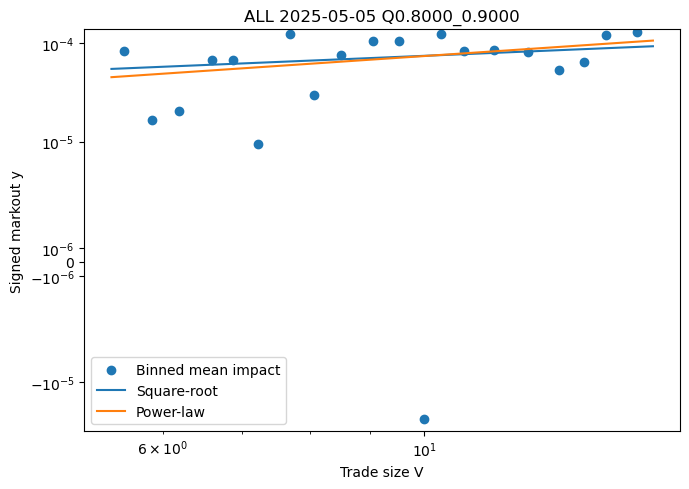

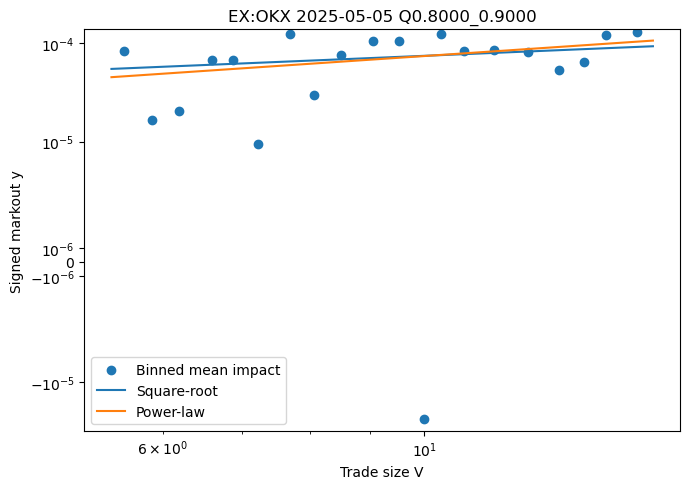

In [8]:
def _subset_for_label(label: str) -> pd.DataFrame:
    if label == "ALL":
        return parents
    if label.startswith("EX:"):
        ex = label.replace("EX:", "", 1)
        return parents[parents["exchange"] == ex]
    return parents

def plot_and_save_row(row):
    lab = row["label"]
    day = row["date"]
    qbin = row["qbin"]

    df_lab = _subset_for_label(lab)

    # consistent with estimator: infer signs using cfg.sign_ref_M and within-exchange markouts
    m = infer_side_signs(
        df_lab,
        getattr(cfg, "sign_ref_M", 1),
        mode=getattr(cfg, "side_map_mode", "infer"),
        tail_q=getattr(cfg, "sign_infer_quantile", 0.8),
        outlier_q=getattr(cfg, "sign_infer_outlier_q", 0.9975),
    )
    mk = add_markouts(df_lab, cfg.M, m)

    # apply same outlier trim and cohorting, then exact slice for (day,qbin)
    mkb = trim_outliers_and_bin(mk, cfg.q_outlier, cfg.q_bins)
    dplot = mkb[(mkb["ts"].dt.date == day) & (mkb["qbin"] == qbin)].copy()
    if dplot.empty:
        return None

    title = f"{lab} {day} {qbin}"
    fig = plot_fit(dplot, row["mu0"], row["mu1"], row["mu2"], title)
    stem = f"fit_{lab}_{day}_{qbin}"
    return save_figure(fig, figdir, stem)

# Save a small fixed set for grading: pooled + first exchange, for one day, for all qbins available that day.
if not results.empty:
    for lab in [c for c in ["ALL"] + sorted([x for x in results["label"].unique() if x != "ALL"])[:1]]:
        sub = results[results["label"] == lab].sort_values(["date","qbin"])
        if sub.empty:
            continue
        day = sub["date"].iloc[0]
        for _, row in sub[sub["date"] == day].iterrows():
            p = plot_and_save_row(row)
            if p is not None:
                print("Saved:", p)


## Diagnostics

In [9]:
rob = robustness_sweep(parents, cfg)
rob.to_parquet(outdir / 'impact_robustness.parquet', index=False)
rob.to_csv(outdir / 'impact_robustness.csv', index=False)
print('Robustness rows:', len(rob))

# Minimal stability summary required by assignment (across days and q-bins)
stab = stability_summary(results)
stab.to_csv(outdir / "impact_stability_summary.csv", index=False)
print("Saved stability summary:", outdir / "impact_stability_summary.csv")
stab.head(20)


Robustness rows: 465
Saved stability summary: C:\Users\Owner\Box\Winter26\QTS\qts\HW7_impact\outputs\impact_stability_summary.csv


,label,qbin,days,n_rows,mu0_med,mu0_iqr,mu2_med,mu2_iqr,mu2_min,mu2_max
0,ALL,Q0.8000_0.9000,11,11,0.000026,0.000003,0.092911,0.250167,0.047426,0.952574
1,ALL,Q0.9000_0.9500,3,3,0.000020,0.000002,0.047426,0.102341,0.047426,0.252108
2,EX:OKX,Q0.8000_0.9000,11,11,0.000026,0.000003,0.092911,0.250167,0.047426,0.952574
3,EX:OKX,Q0.9000_0.9500,3,3,0.000020,0.000002,0.047426,0.102341,0.047426,0.252108


In [10]:
if not rob.empty:
    rob2 = rob.assign(mu2_low=(rob["mu2"]<=0.05), mu2_high=(rob["mu2"]>=0.95))
    display(
        rob2.groupby(["label","M","q_outlier"], observed=True)[["mu2_low","mu2_high"]]
            .mean()
            .reset_index()
            .sort_values(["label","M","q_outlier"])
            .head(30)
    )


,label,M,q_outlier,mu2_low,mu2_high
0,ALL,1,0.9950,0.000000,0.071429
1,ALL,1,0.9975,0.000000,0.071429
2,ALL,1,0.9990,0.000000,0.071429
3,ALL,5,0.9950,0.214286,0.000000
4,ALL,5,0.9975,0.142857,0.000000
5,ALL,5,0.9990,0.142857,0.000000
6,ALL,10,0.9950,0.285714,0.000000
7,ALL,10,0.9975,0.214286,0.000000
8,ALL,10,0.9990,0.214286,0.000000
9,ALL,25,0.9950,0.428571,0.000000


In [11]:
# Auditability: show key implementations directly in the notebook
import impact_core

for fn in ["collapse_multihit_trades", "add_markouts", "trim_outliers_and_bin", "fit_power_exponent_binned", "fit_sqrt_model"]:
    print("\n" + "="*90)
    print(fn)
    print("-"*90)
    print(inspect.getsource(getattr(impact_core, fn)))



collapse_multihit_trades
------------------------------------------------------------------------------------------
def collapse_multihit_trades(df: pd.DataFrame, ts_floor: str | None) -> pd.DataFrame:
    """Collapse multi-hit sweeps into parent trades.

    Without order_id-level data, aggregate *consecutive* prints that are:
      (i) same exchange, (ii) same side label, (iii) within a timestamp tolerance.

    Interprets ts_floor as a tolerance (e.g., '1ms'), to avoid merging non-consecutive trades
    that merely share the same floored timestamp.

    Parent-trade construction:
      - qty: sum(qty)
      - price: VWAP = sum(price*qty)/sum(qty)
      - ts: first timestamp in the run
    """
    if df.empty:
        return df.copy()

    tol = pd.Timedelta(0) if ts_floor is None else pd.Timedelta(str(ts_floor))

    d = df[["ts", "qty", "price", "exchange", "side"]].copy()
    d = d.sort_values(["exchange", "ts"], kind="mergesort").reset_index(drop=True)
    d["pxq"] = d["price"] 

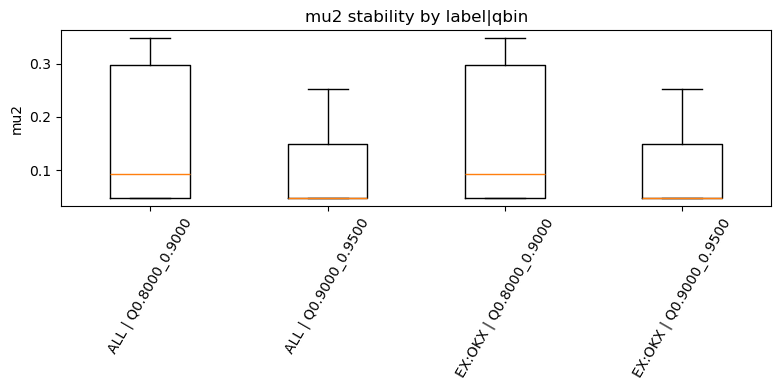

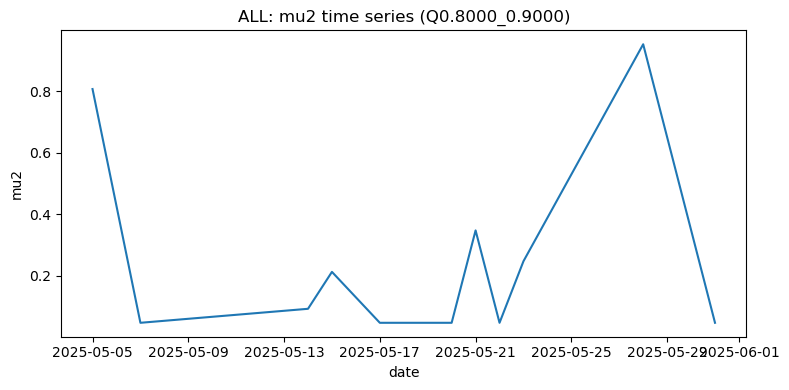

In [12]:
# Stability visuals (required comparisons across cohorts)
if not results.empty:
    # Boxplot of mu2 across (label,qbin)
    fig = plot_param_box(results, "mu2", "mu2 stability by label|qbin")
    save_figure(fig, figdir, "stability_mu2_box")

    # Time-series on pooled (if present)
    if "ALL" in set(results["label"]):
        qbin = results[results["label"]=="ALL"]["qbin"].value_counts().index[0]
        fig = plot_param_timeseries(results, "ALL", qbin, "mu2", f"ALL: mu2 time series ({qbin})")
        save_figure(fig, figdir, f"stability_mu2_ts_ALL_{qbin}")
